# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# leer conjuntos de datos en los DataFrames
df_orders = pd.read_csv('../data/instacart_orders.csv',sep=';')
df_products = pd.read_csv('../data/products.csv', sep=';')
df_aisles = pd.read_csv('../data/aisles.csv', sep=';')
df_departments = pd.read_csv('../data/departments.csv', sep=';')
df_order_products = pd.read_csv('../data/order_products.csv', sep=';')

In [3]:
# mostrar información del DataFrame
df_orders.info()
df_orders.head()

<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [4]:
# mostrar información del DataFrame
df_products.info()
df_products.head()

<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [5]:
# mostrar información del DataFrame
df_aisles.info()
df_aisles.head()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.2 KB


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [6]:
# mostrar información del DataFrame
df_departments.info()
df_departments.head()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [7]:
# mostrar información del DataFrame
df_order_products.info()
df_order_products.head()

<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


## Conclusiones
Se tendrá que realizar varios merge para juntar los disitintos conjutos de datos. Cada arreglo de datos comparte al menos una columna de otro dataframe por lo tanto es posible hacer los "merge" nesesarios para relacionar la información y tener un arreglo de datos completo para analizar. 
Revisando los tipos de datos de cada columna si es necesario en algunos cambiar el tipo de dato, duplicados y datos ausentes.  

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Primero verificar y corregir los tipos de datos. A los que no estoy muy seguro aplicaré el método 'array_equal()' si es posible hacer el cambio de tipo de dato. Despúes encontrar duplicados y datos ausentes. 

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
#print(df_orders.dtypes)
#df_orders['days_since_prior_order'] = df_orders['days_since_prior_order'].astype('int')
#Si el pedido es el primero del cliente (no hay días anteriores), aparece NaN por lo tanto se llena con '0' y se cambia a entero
#df_orders['days_since_prior_order'] = df_orders['days_since_prior_order'].fillna(0).astype(int)
print(df_orders.duplicated().sum())

print(df_orders[df_orders.duplicated()])



15
        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48         

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?
Hay 15 filas duplicadas, y tienen en comun el día y la hora que se relizaron las ordenes. 

In [9]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
df_wed_2am=df_orders[(df_orders['order_dow']==3)&(df_orders['order_hour_of_day']==2)]

#Duplicados exactos
df_duplicados = df_wed_2am[df_wed_2am.duplicated()]
print(df_duplicados)

#Los duplicados comparten el mismo order_id
print()
print('Duplicados del miercoles a las 2:00am con el mismno order_id :')    
print(df_duplicados['order_id'].value_counts())

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

¿Qué sugiere este resultado?

R: Se puede ver que que los order_id no se repiten con los duplicados del miercoles a las 2:00 am, entonces probablemente es un comportamiento sistemático (órdenes automáticas) y no por usuarios manualmente.

In [10]:
# Elimina los pedidos duplicados
df_orders=df_orders.drop_duplicates()

In [11]:
# Vuelve a verificar si hay filas duplicadas
print(df_orders.duplicated().sum())


0


In [12]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
duplicados_order_id = df_orders[df_orders['order_id'].duplicated(keep=False)]

print("Cantidad de pedidos duplicados:", duplicados_order_id['order_id'].nunique())
print("IDs duplicados:", duplicados_order_id['order_id'].unique())

Cantidad de pedidos duplicados: 0
IDs duplicados: []


Describe brevemente tus hallazgos y lo que hiciste con ellos
R: No hay IDs duplicados de pedidos 

### `products` data frame

In [13]:
# Verifica si hay filas totalmente duplicadas
df_products['product_name']= df_products['product_name'].astype('string')
#df_products.info()
print(df_products.duplicated().sum())


0


In [14]:
# Revisa únicamente si hay ID de productos duplicados
print(df_products['product_id'].duplicated().sum())

0


In [15]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
df_products['product_name']=df_products['product_name'].str.upper()
#df_products.head()
print(df_products['product_name'].duplicated().sum())

1361


In [16]:
# Revisa si hay nombres duplicados de productos no faltantes
productos_duplicados = df_products[df_products['product_name'].notna() & df_products['product_name'].duplicated(keep=False)]

print("Cantidad de productos con nombres duplicados:", productos_duplicados['product_name'].nunique())
print(productos_duplicados['product_name'].value_counts())

Cantidad de productos con nombres duplicados: 103
product_name
GREEN TEA WITH GINSENG AND HONEY              3
BIOTIN 1000 MCG                               2
FRESH SCENT DISHWASHER DETERGENT WITH DAWN    2
AMERICAN CHEESE SLICES                        2
CAULIFLOWER HEAD                              2
                                             ..
SPREADABLE BUTTER WITH CANOLA OIL             2
BURRITO- STEAK & CHEESE                       2
COOKIES 'N CREAM ICE CREAM                    2
PINEAPPLE SLICES IN 100% PINEAPPLE JUICE      2
VITAMIN D3 5000 IU                            2
Name: count, Length: 103, dtype: Int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `departments` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
df_departments['department']= df_departments['department'].astype('string')
#df_departments.info()
print(df_departments.duplicated().sum())

0


In [18]:
# Revisa únicamente si hay IDs duplicadas de departamentos
duplicados_department_id = df_departments[df_departments['department_id'].duplicated(keep=False)]

print("Cantidad de pedidos duplicados:", duplicados_department_id['department_id'].nunique())
print("IDs duplicados:", duplicados_department_id['department_id'].unique())

Cantidad de pedidos duplicados: 0
IDs duplicados: []


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `aisles` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
df_aisles['aisle']= df_aisles['aisle'].astype('string')
#df_aisles.info()
print(df_aisles.duplicated().sum())

0


In [20]:
# Revisa únicamente si hay IDs duplicadas de pasillos
duplicados_aisle_id = df_aisles[df_aisles['aisle_id'].duplicated(keep=False)]

print("Cantidad de pedidos duplicados:", duplicados_aisle_id['aisle_id'].nunique())
print("IDs duplicados:", duplicados_aisle_id['aisle_id'].unique())

Cantidad de pedidos duplicados: 0
IDs duplicados: []


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `order_products` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
print(df_order_products.duplicated().sum())

0


In [22]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(df_order_products.value_counts())

order_id  product_id  add_to_cart_order  reordered
2141543   11440       17.0               0            1
567889    1560        1.0                1            1
2261212   26683       1.0                1            1
491251    8670        35.0               1            1
2571142   1940        5.0                1            1
                                                     ..
577211    15290       12.0               1            1
1219554   21914       9.0                0            1
692640    47766       4.0                1            1
319435    691         8.0                1            1
1398151   28733       9.0                0            1
Name: count, Length: 4544171, dtype: int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [23]:
# Encuentra los valores ausentes en la columna 'product_name'
df_product_names=df_products[df_products['product_name'].isna()]
print(df_product_names)

       product_id product_name  aisle_id  department_id
37             38         <NA>       100             21
71             72         <NA>       100             21
109           110         <NA>       100             21
296           297         <NA>       100             21
416           417         <NA>       100             21
...           ...          ...       ...            ...
49552       49553         <NA>       100             21
49574       49575         <NA>       100             21
49640       49641         <NA>       100             21
49663       49664         <NA>       100             21
49668       49669         <NA>       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos.

In [24]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
print(df_product_names[df_product_names['aisle_id']==100])

       product_id product_name  aisle_id  department_id
37             38         <NA>       100             21
71             72         <NA>       100             21
109           110         <NA>       100             21
296           297         <NA>       100             21
416           417         <NA>       100             21
...           ...          ...       ...            ...
49552       49553         <NA>       100             21
49574       49575         <NA>       100             21
49640       49641         <NA>       100             21
49663       49664         <NA>       100             21
49668       49669         <NA>       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos.

In [25]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print(df_product_names[df_product_names['department_id']==21])

       product_id product_name  aisle_id  department_id
37             38         <NA>       100             21
71             72         <NA>       100             21
109           110         <NA>       100             21
296           297         <NA>       100             21
416           417         <NA>       100             21
...           ...          ...       ...            ...
49552       49553         <NA>       100             21
49574       49575         <NA>       100             21
49640       49641         <NA>       100             21
49663       49664         <NA>       100             21
49668       49669         <NA>       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos.

In [26]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
df_department_21=df_departments[df_departments['department_id']==21]
print(df_department_21)
df_aisle_100=df_aisles[df_aisles['aisle_id']==100]
print(df_aisle_100)


    department_id department
20             21    missing
    aisle_id    aisle
99       100  missing


Describe brevemente cuáles son tus hallazgos.
R: Los productos son del departamento y pasillo de "missing"

In [27]:
# Completa los nombres de productos ausentes con 'Unknown'
df_products['product_name']=df_products['product_name'].fillna('Unknown')
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   49694 non-null  string
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), string(1)
memory usage: 1.5 MB


Describe brevemente tus hallazgos y lo que hiciste con ellos.
R: Ahora df_products ya no tiene valores nulos 

### `orders` data frame

In [28]:
# Encuentra los valores ausentes
#df_orders.info()
df_orders_na= df_orders[df_orders['days_since_prior_order'].isna()]
print(df_orders_na)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [29]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
print(df_orders_na[~df_orders_na['order_number']==1])

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Describe brevemente tus hallazgos y lo que hiciste con ellos.
R: todos los valores ausentes si son de los clientes que pidieron por primera vez 

### `order_products` data frame

In [30]:
# Encuentra los valores ausentes
print(df_order_products.isna().sum())
print(df_order_products[df_order_products['add_to_cart_order'].isna()])

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64
         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [31]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
cart_min=df_order_products['add_to_cart_order'].min()
cart_max=df_order_products['add_to_cart_order'].max()
print(f"El valor mínimo de la columna 'add_to_cart_order' : {cart_min}")
print(f"El valor máximo de la columna 'add_to_cart_order' : {cart_max}")
valores_add_to_cart=df_order_products['add_to_cart_order'].sort_values(ascending=True)
print(valores_add_to_cart.head())
print(valores_add_to_cart.tail())

El valor mínimo de la columna 'add_to_cart_order' : 1.0
El valor máximo de la columna 'add_to_cart_order' : 64.0
4544978    1.0
33         1.0
450147     1.0
3399962    1.0
3399957    1.0
Name: add_to_cart_order, dtype: float64
4505662   NaN
4511400   NaN
4517562   NaN
4534112   NaN
4535739   NaN
Name: add_to_cart_order, dtype: float64


Describe brevemente cuáles son tus hallazgos.
R: los valores ausentes pueden ser mayores que 64

In [32]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
df_order_products_na=df_order_products[df_order_products['add_to_cart_order'].isna()]
df_ids_na=df_order_products_na['order_id']
print(df_ids_na.head())

737      2449164
9926     1968313
14394    2926893
16418    1717990
30114    1959075
Name: order_id, dtype: int64


In [33]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
print(df_order_products_na.groupby(['order_id'])['product_id'].count())

order_id
9310        1
61355      63
102236     31
129627      5
165801      6
           ..
2999801     6
3125735    22
3308010    51
3347453     7
3383594     5
Name: product_id, Length: 70, dtype: int64


Describe brevemente cuáles son tus hallazgos.
R: No todos los pedidos con valores ausentes tienen más de 64 productos

In [34]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
df_order_products['add_to_cart_order']=df_order_products['add_to_cart_order'].fillna(999).astype('int')
df_order_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB


In [35]:
cart_min=df_order_products['add_to_cart_order'].min()
cart_max=df_order_products['add_to_cart_order'].max()
print(f"El valor mínimo de la columna 'add_to_cart_order' : {cart_min}")
print(f"El valor máximo de la columna 'add_to_cart_order' : {cart_max}")
valores_add_to_cart=df_order_products['add_to_cart_order'].sort_values(ascending=True)
print(valores_add_to_cart.head())
print(valores_add_to_cart.tail())

El valor mínimo de la columna 'add_to_cart_order' : 1
El valor máximo de la columna 'add_to_cart_order' : 999
1653004    1
4544946    1
4544942    1
4544941    1
45         1
Name: add_to_cart_order, dtype: int64
895008     999
1514664    999
2982614    999
4346034    999
641294     999
Name: add_to_cart_order, dtype: int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.

## Conclusiones

En el paso dos fue el identificar valores ausentes y duplicados en cada dataframe. Se hizo una limpia de de filas duplicadas, identificación de valores nulos y cambiarlos por un valor para continuar con los analisis posteriores. 


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [36]:
hours_ok = ((df_orders['order_hour_of_day'] >= 0) & (df_orders['order_hour_of_day'] <= 23)).all()
if hours_ok :
    print("Todos los valores son estan dentro del rango de 0 - 23.")
else:
    print("Hay valores fuera de rango.")

Todos los valores son estan dentro del rango de 0 - 23.


In [37]:
dow_ok = ((df_orders['order_dow'] >= 0) & (df_orders['order_dow'] <= 6)).all()
if dow_ok :
    print("Todos los valores son estan dentro del rango de 0 - 6.")
else:
    print("Hay valores fuera de rango.")

Todos los valores son estan dentro del rango de 0 - 6.


Los valores estan dentro de los rangos, no hay anomalias o errores en el tiempo y días. 

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

In [38]:
usuarios_por_hora = (
    df_orders
    .groupby('order_hour_of_day')['user_id']
    .nunique()
    .reindex(range(24), fill_value=0)  # Asegura que aparezcan todas las horas de 0 a 23
)

print(usuarios_por_hora)

order_hour_of_day
0      2991
1      1671
2       958
3       744
4       735
5      1281
6      3757
7     10993
8     20268
9     28112
10    32195
11    32660
12    31754
13    32433
14    32797
15    32894
16    31579
17    26825
18    21795
19    17026
20    12891
21     9806
22     7670
23     5167
Name: user_id, dtype: int64


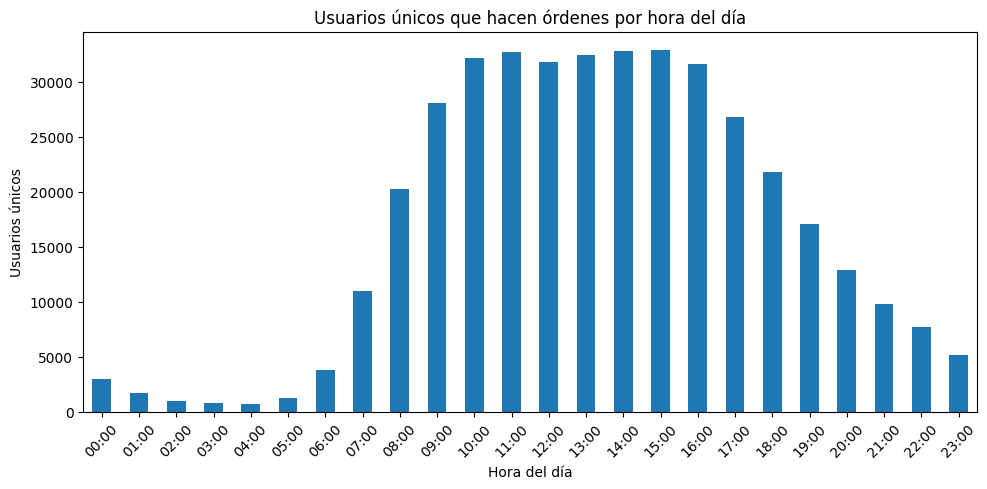

In [39]:
usuarios_por_hora.plot(kind='bar', figsize=(10,5))
plt.xlabel('Hora del día')
plt.ylabel('Usuarios únicos')
plt.title('Usuarios únicos que hacen órdenes por hora del día')
plt.xticks(range(24), [f"{h:02d}:00" for h in range(24)], rotation=45)
plt.tight_layout()
plt.show()

La mayor actividad de los usuarios al hacer sus ordenes son desde las 10:00 hrs a las 15:00 hrs

### [A3] ¿Qué día de la semana compran víveres las personas?

In [40]:
usuarios_por_dia = (
    df_orders
    .groupby('order_dow')['user_id']
    .nunique()
    .reindex(range(7), fill_value=0)  # asegura que estén los 7 días
)

print(usuarios_por_dia)

order_dow
0    57661
1    56479
2    48587
3    45331
4    44281
5    46127
6    45604
Name: user_id, dtype: int64


In [41]:
dias_semana = {0: 'Domingo', 1: 'Lunes', 2: 'Martes', 3: 'Miércoles', 
               4: 'Jueves', 5: 'Viernes', 6: 'Sábado'}

usuarios_por_dia.index = usuarios_por_dia.index.map(dias_semana)
print(usuarios_por_dia)

order_dow
Domingo      57661
Lunes        56479
Martes       48587
Miércoles    45331
Jueves       44281
Viernes      46127
Sábado       45604
Name: user_id, dtype: int64


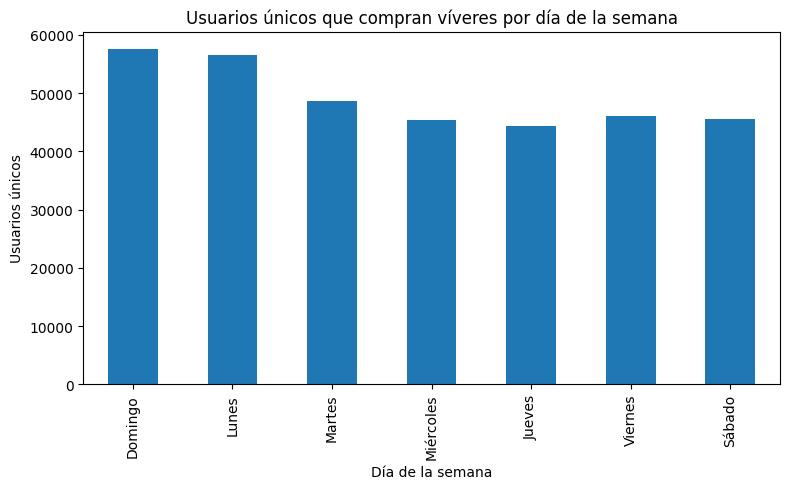

In [42]:
usuarios_por_dia.plot(kind='bar', figsize=(8,5))
plt.xlabel('Día de la semana')
plt.ylabel('Usuarios únicos')
plt.title('Usuarios únicos que compran víveres por día de la semana')
plt.tight_layout()
plt.show()

El día de la semana que prefieren los usuarios para comprar víveres el día Domingo seguido del Lunes.  

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

In [43]:
estadisticas = df_orders['days_since_prior_order'].describe()
print(estadisticas)
valor_min = df_orders['days_since_prior_order'].min()
valor_max = df_orders['days_since_prior_order'].max()

print(f"\nValor mínimo: {valor_min} días")
print(f"Valor máximo: {valor_max} días")

count    450135.000000
mean         11.101814
std           9.190004
min           0.000000
25%           4.000000
50%           7.000000
75%          15.000000
max          30.000000
Name: days_since_prior_order, dtype: float64

Valor mínimo: 0.0 días
Valor máximo: 30.0 días


En promedio las personas tardan 11 días para hacer otro pedido y máximo tardan 30 días para realizar otro pedido. 

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [44]:
miercoles = df_orders[df_orders['order_dow'] == 3]
sabado = df_orders[df_orders['order_dow'] == 6]

In [46]:
miercoles_counts = miercoles.groupby('order_hour_of_day').size().reindex(range(24), fill_value=0)
sabado_counts = sabado.groupby('order_hour_of_day').size().reindex(range(24), fill_value=0)

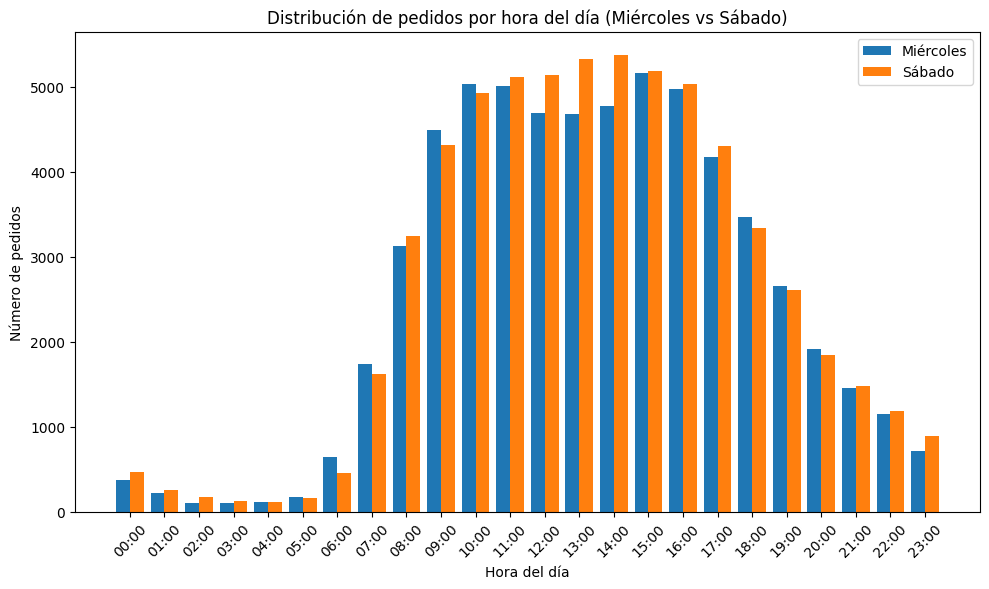

In [47]:
plt.figure(figsize=(10,6))
plt.bar(miercoles_counts.index - 0.2, miercoles_counts, width=0.4, label='Miércoles')
plt.bar(sabado_counts.index + 0.2, sabado_counts, width=0.4, label='Sábado')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')
plt.title('Distribución de pedidos por hora del día (Miércoles vs Sábado)')
plt.xticks(range(24), [f"{h:02d}:00" for h in range(24)],rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Se oberserva que a las 12:00 a 14:00 hrs hay mas número de pedidos el día sabado a compración del día miercoles. De 9:00 a 10:00 hrs, el miércoles tiene más actividad. En los demás horarios tienen una actividad similar ambos días.  

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [48]:
ordenes_por_cliente = df_orders.groupby('user_id').size()
distribucion = ordenes_por_cliente.value_counts().sort_index()

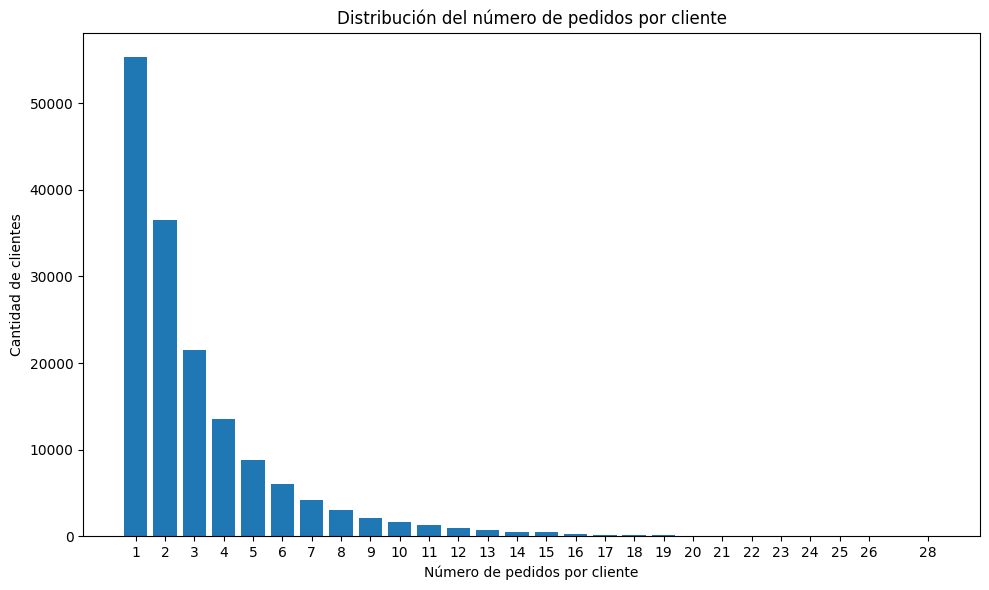

In [49]:
plt.figure(figsize=(10,6))
plt.bar(distribucion.index, distribucion.values)

plt.xlabel('Número de pedidos por cliente')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución del número de pedidos por cliente')
plt.xticks(distribucion.index)  # mostrar todas las cantidades en el eje X
plt.tight_layout()
plt.show()

Se puede observar que menos de 40000 clientes realizan su segundo pedido, y menos de 30000 clientes realizan su tercer pedido. La cantidad de numeros de pedidos va disminuyendo por lo tanto se puede decir que se van perdinedo clientes.  

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [50]:
product_counts = (
    df_order_products.groupby("product_id")
    .size()
    .reset_index(name="num_orders")
)
product_counts = product_counts.sort_values("num_orders", ascending=False)


In [51]:
top_products = product_counts.merge(df_products, on="product_id", how="left")
top_20 = top_products.head(20)

In [52]:
print(top_20[["product_id", "product_name", "num_orders"]])

    product_id              product_name  num_orders
0        24852                    BANANA       66050
1        13176    BAG OF ORGANIC BANANAS       53297
2        21137      ORGANIC STRAWBERRIES       37039
3        21903      ORGANIC BABY SPINACH       33971
4        47209      ORGANIC HASS AVOCADO       29773
5        47766           ORGANIC AVOCADO       24689
6        47626               LARGE LEMON       21495
7        16797              STRAWBERRIES       20018
8        26209                     LIMES       19690
9        27845        ORGANIC WHOLE MILK       19600
10       27966       ORGANIC RASPBERRIES       19197
11       22935      ORGANIC YELLOW ONION       15898
12       24964            ORGANIC GARLIC       15292
13       45007          ORGANIC ZUCCHINI       14584
14       39275       ORGANIC BLUEBERRIES       13879
15       49683            CUCUMBER KIRBY       13675
16       28204        ORGANIC FUJI APPLE       12544
17        5876             ORGANIC LEMON      

Se tuvo que hacer un merge entre los dataframe de order_products y products. En el top 20 de productos populares esta la "BANANA" con 66050 ordenes, en segundo lugar es "BAG OF ORGANIC BANANAS" al parecer los usuarios les gusta mucho los platanos. En tercer Lugar estas la Fresas organicas. En el Ultimo lugar en este Top 20 se encuentra "ORGANIC GRAPE TOMATOES"

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [53]:
items_per_order = (
    df_order_products.groupby("order_id")
    .size()
    .reset_index(name="num_items")
)

In [54]:
print(items_per_order["num_items"].describe())

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: num_items, dtype: float64


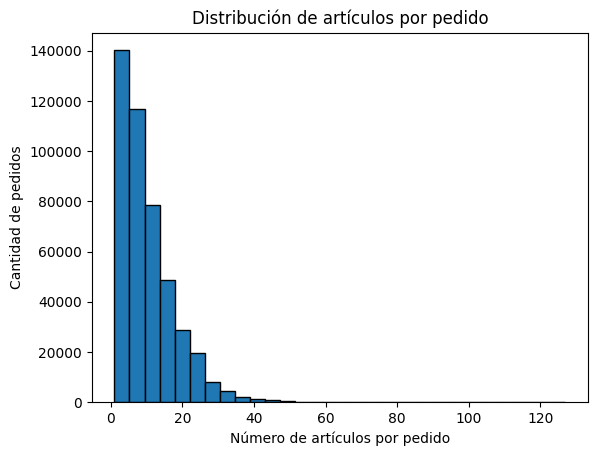

In [55]:
plt.hist(items_per_order["num_items"], bins=30, edgecolor='black')
plt.xlabel("Número de artículos por pedido")
plt.ylabel("Cantidad de pedidos")
plt.title("Distribución de artículos por pedido")
plt.show()

La mayoria de los pedidos no contienen muchos productos. Muy pocos pedidos son de mas de 40 artículos. 

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [56]:
reordered_items = df_order_products[df_order_products["reordered"] == 1]
reorder_counts = (
    reordered_items.groupby("product_id")
    .size()
    .reset_index(name="num_reorders")
)

In [57]:
reorder_counts = reorder_counts.sort_values("num_reorders", ascending=False)
top_reordered = reorder_counts.merge(df_products, on="product_id", how="left")


In [58]:
top_20_reordered = top_reordered.head(20)

In [59]:
print(top_20_reordered[["product_id", "product_name", "num_reorders"]])

    product_id              product_name  num_reorders
0        24852                    BANANA         55763
1        13176    BAG OF ORGANIC BANANAS         44450
2        21137      ORGANIC STRAWBERRIES         28639
3        21903      ORGANIC BABY SPINACH         26233
4        47209      ORGANIC HASS AVOCADO         23629
5        47766           ORGANIC AVOCADO         18743
6        27845        ORGANIC WHOLE MILK         16251
7        47626               LARGE LEMON         15044
8        27966       ORGANIC RASPBERRIES         14748
9        16797              STRAWBERRIES         13945
10       26209                     LIMES         13327
11       22935      ORGANIC YELLOW ONION         11145
12       24964            ORGANIC GARLIC         10411
13       45007          ORGANIC ZUCCHINI         10076
14       49683            CUCUMBER KIRBY          9538
15       28204        ORGANIC FUJI APPLE          8989
16        8277  APPLE HONEYCRISP ORGANIC          8836
17       3

Este los primeros tres lugares de este top 20 de productos que vuelven a pedir, coincide con los tres primerps lugares del top 20 de los productos más populares. Sin embargo el ultimo lugar de este top 20 es diferente del otro. 

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [60]:
total_orders = (
    df_order_products.groupby("product_id")
    .size()
    .reset_index(name="total_orders")
)

In [61]:
repeat_orders = (
    df_order_products[df_order_products["reordered"] == 1]
    .groupby("product_id")
    .size()
    .reset_index(name="repeat_orders")
)

In [62]:
repeat_rate_df = pd.merge(total_orders, repeat_orders, on="product_id", how="left")
repeat_rate_df["repeat_orders"] = repeat_rate_df["repeat_orders"].fillna(0)
repeat_rate_df["repeat_rate"] = repeat_rate_df["repeat_orders"] / repeat_rate_df["total_orders"] #tasa de repetición
repeat_rate_df = repeat_rate_df[repeat_rate_df["total_orders"] >= 50]
repeat_rate_df = repeat_rate_df.merge(df_products, on="product_id", how="left")
top_repeat_rate = repeat_rate_df.sort_values("repeat_rate", ascending=False).head(20)

print(top_repeat_rate[["product_id", "product_name", "total_orders", "repeat_orders", "repeat_rate"]])

       product_id                             product_name  total_orders  \
10016       48041  DANACTIVE VANILLA PROBIOTIC DAIRY DRINK            65   
6842        32978                       LEMON LIME SELTZER            66   
8324        39782      ORGANIC RASPBERRY MATE ENERGY DRINK            65   
3630        17469                     LO-CARB ENERGY DRINK            63   
5172        25000         WHOLE WHEAT MULTIGRAIN POP CAKES            53   
10029       48095                   PURIFIED WATER- 9.5PH+            57   
1932         9292          HALF AND HALF ULTRA PASTEURIZED           397   
563          2677        YERBA MATE SPARKLING CLASSIC GOLD           171   
9863        47231                     ULTRA-PURIFIED WATER           205   
224          1157                     WHEAT SANDWICH BREAD           147   
9487        45504               WHOLE ORGANIC OMEGA 3 MILK          1286   
6099        29447                 MILK- ORGANIC- VITAMIN D          2880   
7116        

Se puede identificar que productos se piden y se vuelven a pedir.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [63]:
df = df_order_products.merge(df_orders[["order_id", "user_id"]], on="order_id", how="left")
user_totals = (
    df.groupby("user_id")
    .size()
    .reset_index(name="total_items")
)

user_repeats = (
    df[df["reordered"] == 1]
    .groupby("user_id")
    .size()
    .reset_index(name="repeat_items")
)

In [64]:
user_repeat_rate = pd.merge(user_totals, user_repeats, on="user_id", how="left")
user_repeat_rate["repeat_items"] = user_repeat_rate["repeat_items"].fillna(0)
user_repeat_rate["repeat_rate"] = user_repeat_rate["repeat_items"] / user_repeat_rate["total_items"]
print(user_repeat_rate.head(20))

    user_id  total_items  repeat_items  repeat_rate
0         2           26           1.0     0.038462
1         4            2           0.0     0.000000
2         5           12           8.0     0.666667
3         6            4           0.0     0.000000
4         7           14          13.0     0.928571
5        11           15           3.0     0.200000
6        12           12           3.0     0.250000
7        13           23          13.0     0.565217
8        14           61          22.0     0.360656
9        15           13           7.0     0.538462
10       16           32          17.0     0.531250
11       17           53          38.0     0.716981
12       19           48          14.0     0.291667
13       20            4           0.0     0.000000
14       21           20           8.0     0.400000
15       22            6           6.0     1.000000
16       24            2           1.0     0.500000
17       26           16           7.0     0.437500
18       27 

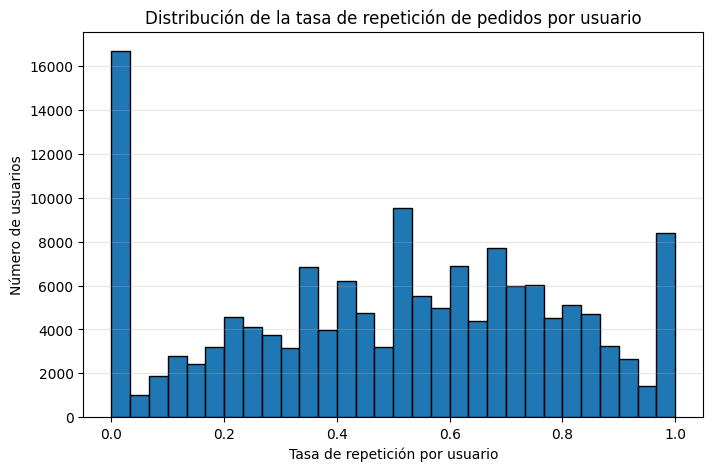

In [65]:
plt.figure(figsize=(8, 5))
plt.hist(user_repeat_rate["repeat_rate"], bins=30, edgecolor="black")
plt.xlabel("Tasa de repetición por usuario")
plt.ylabel("Número de usuarios")
plt.title("Distribución de la tasa de repetición de pedidos por usuario")
plt.grid(axis="y", alpha=0.3)
plt.show()

Aproximadamente mas de 8000 usuarios llegan a repetir los productos en los siguientes pedidos que realiza. Sin embargo mas de 16000 usuarios no repiten sus pedidos. 

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [66]:
first_items = df_order_products[df_order_products["add_to_cart_order"] == 1]
first_counts = (
    first_items.groupby("product_id")
    .size()
    .reset_index(name="first_count")
)

In [67]:
first_counts = first_counts.sort_values("first_count", ascending=False)
first_counts = first_counts.merge(df_products, on="product_id", how="left")

In [68]:
top_first = first_counts.head(20)
print(top_first[["product_id", "product_name", "first_count"]])

    product_id                 product_name  first_count
0        24852                       BANANA        15562
1        13176       BAG OF ORGANIC BANANAS        11026
2        27845           ORGANIC WHOLE MILK         4363
3        21137         ORGANIC STRAWBERRIES         3946
4        47209         ORGANIC HASS AVOCADO         3390
5        21903         ORGANIC BABY SPINACH         3336
6        47766              ORGANIC AVOCADO         3044
7        19660                 SPRING WATER         2336
8        16797                 STRAWBERRIES         2308
9        27966          ORGANIC RASPBERRIES         2024
10       44632   SPARKLING WATER GRAPEFRUIT         1914
11       49235          ORGANIC HALF & HALF         1797
12       47626                  LARGE LEMON         1737
13         196                         SODA         1733
14       38689     ORGANIC REDUCED FAT MILK         1397
15       26209                        LIMES         1370
16       12341                H

Además de ser populares, de ser los productos que vuelven a pedir son los que primero ingresan al carrito, las BANANAS es el producto estrella de los usuarios. 

### Conclusion general del proyecto:

El producto estrella es sin duda las BANANAS y la bolsa de bananas orgánicas. Sin emebargo viarios usarios dejan de volver hacer pedidos o no piden lo mismo en su pedidos posteriores. Es podría ser un mensaje o aviso para checar la calidad de los productos, por ejemplo un buen punto de partida sería revisar la tasa de reordemiento de los productos empezando por el de menor tasa, ¿Por que no lo vuelven a pedir?. El obejtivo de mejora será que mas usuarios vuelvan a realizar sus pedidos e identificar los productos estrella o la canasta basica para tus usuarios y así aplicar interesantes promociones u ofertas para incentivar a los usuarios que vuelban a surtir su alacena en esta tienda.  